<a href="https://colab.research.google.com/github/dede0702/Image-Analysis-for-Ad-Differentiation/blob/Sprint-1/Image_Analysis_for_Ad_Differentiation_PT1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
Sprint 1: Estruturação de Dados - Identificando Diferenças em Anúncios
```





```
0. Setup e Importações
```



In [ ]:
!pip install tensorflow Pillow scikit-learn matplotlib opencv-python # OpenCV para pré-processamento se necessário

In [ ]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from PIL import Image, UnidentifiedImageError
import shutil # Para copiar arquivos

In [ ]:
# Reprodutibilidade
tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
print(tf.__version__)
print(keras.__version__)

2.18.0
3.8.0


In [ ]:
# Helper function for plotting images (usado em H2)
def plot_images_h2(images, labels=None, title="", n_cols=5):
    n_rows = (len(images) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 3, n_rows * 3))
    plt.suptitle(title, fontsize=16)
    for i, img in enumerate(images):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(img)
        if labels is not None:
            plt.title(labels[i])
        plt.axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()



```
1. MONTAGEM DO DATASET (GOOGLE DRIVE) E PRÉ-PROCESSAMENTO INICIAL DE IMAGENS
```



In [ ]:
# Montar o Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ------------------------------------------------------------------------------------
# ATENÇÃO USUÁRIO:
# Modifique o caminho abaixo para apontar para a pasta raiz do seu dataset no Google Drive.
# A estrutura esperada dentro desta pasta é:
# SEU_CAMINHO_NO_DRIVE/
# ├── HP_Original/               <-- Imagens para H1, classe "HP_Original"
# │   ├── imagem1.jpeg
# │   └── ...
# ├── Outros/                    <-- Imagens para H1, classe "Outros"
# │   ├── imagemX.jpeg
# │   └── ...
# └── general_ads_for_embeddings/  <-- Imagens para H2 (anúncios diversos para análise de similaridade)
#     ├── anuncio1.jpeg
#     └── ...
# Somente arquivos .jpeg ou .jpg dentro dessas subpastas serão considerados para processamento.
# ------------------------------------------------------------------------------------

In [ ]:
original_dataset_root_path_drive = pathlib.Path('/content/drive/MyDrive/Colab Notebooks/SPRINT1_HP_Challenge_Dataset') # <--- MUDE ESTE CAMINHO

# Criar um diretório local para as imagens processadas (apenas JPEGs válidos)
# Este diretório conterá as subpastas 'HP_Original', 'Outros', e 'general_ads_for_embeddings' processadas
processed_dataset_local_path = pathlib.Path("dataset_processed_local")
if processed_dataset_local_path.exists():
    shutil.rmtree(processed_dataset_local_path) # Limpa se já existir para evitar duplicatas
processed_dataset_local_path.mkdir(exist_ok=True)
print(f"Dataset original (raiz no Drive): {original_dataset_root_path_drive}")
print(f"Imagens válidas serão copiadas e processadas para (local): {processed_dataset_local_path}\n")

# Parâmetros para processamento de imagem
INPUT_IMAGE_EXTENSIONS = ['.jpeg', '.jpg']
TARGET_EXTENSION = '.jpeg'
TARGET_PIL_FORMAT = 'JPEG'

# Função para processar e copiar imagens de uma pasta de origem (Drive) para destino (local)
def process_and_copy_images(source_base_path, dest_base_path, subfolder_name):
    source_folder = source_base_path / subfolder_name
    dest_folder = dest_base_path / subfolder_name

    if not source_folder.exists():
        print(f"AVISO: Pasta de origem '{source_folder}' não encontrada no Google Drive. Pulando...")
        return 0, 0, 0 # processed, skipped, errors

    dest_folder.mkdir(parents=True, exist_ok=True)
    print(f"\nProcessando pasta: {source_folder} -> {dest_folder}")

    _processed_count = 0
    _skipped_non_target_ext_count = 0
    _error_count = 0

    for input_file_path in source_folder.glob('*'): # Itera sobre todos os arquivos na pasta de origem
        if input_file_path.is_file():
            file_ext_lower = input_file_path.suffix.lower()

            if file_ext_lower in INPUT_IMAGE_EXTENSIONS:
                try:
                    img = Image.open(input_file_path)
                    img.verify() # Verifica integridade básica

                    # Reabre a imagem após verify() para poder processar
                    img = Image.open(input_file_path)

                    output_stem = input_file_path.stem
                    output_filename = output_stem + TARGET_EXTENSION
                    current_output_file_path = dest_folder / output_filename

                    counter = 0 # Lida com nomes de arquivo duplicados no destino
                    while current_output_file_path.exists():
                        counter += 1
                        output_filename = f"{output_stem}_{counter}{TARGET_EXTENSION}"
                        current_output_file_path = dest_folder / output_filename

                    img.convert('RGB').save(current_output_file_path, TARGET_PIL_FORMAT)
                    _processed_count += 1

                except UnidentifiedImageError:
                    print(f"  IGNORADO (Pillow UnidentifiedImageError - arquivo corrompido ou não é imagem válida): {input_file_path.name}")
                    _error_count += 1
                except FileNotFoundError:
                    print(f"  ERRO (Arquivo Não Encontrado): {input_file_path.name}")
                    _error_count += 1
                except Exception as e:
                    print(f"  ERRO ao processar {input_file_path.name}: {e}")
                    _error_count += 1
            else:
                # print(f"  IGNORADO (Não é {INPUT_IMAGE_EXTENSIONS}): {input_file_path.name}") # Descomente para log verboso
                _skipped_non_target_ext_count += 1
    print(f"  Concluído para '{subfolder_name}': {_processed_count} processadas, {_skipped_non_target_ext_count} ignoradas (extensão), {_error_count} erros.")
    return _processed_count, _skipped_non_target_ext_count, _error_count

Dataset original (raiz no Drive): /content/drive/MyDrive/Colab Notebooks/SPRINT1_HP_Challenge_Dataset
Imagens válidas serão copiadas e processadas para (local): dataset_processed_local



In [ ]:
# Processar as pastas necessárias
folders_to_process_h1 = ["HP_Original", "Outros"] # Para H1
folders_to_process_h2 = ["general_ads_for_embeddings"] # Para H2

total_processed = 0
total_skipped = 0
total_errors = 0

print(f"--- Iniciando Pré-processamento e Cópia de Imagens (Drive -> Local) ---")
print(f"Serão processados apenas arquivos com extensões: {INPUT_IMAGE_EXTENSIONS}.")
print(f"Imagens válidas serão salvas como {TARGET_EXTENSION} no formato {TARGET_PIL_FORMAT} (modo RGB).\n")

--- Iniciando Pré-processamento e Cópia de Imagens (Drive -> Local) ---
Serão processados apenas arquivos com extensões: ['.jpeg', '.jpg'].
Imagens válidas serão salvas como .jpeg no formato JPEG (modo RGB).



In [ ]:
# Processa pastas para H1
for folder_name in folders_to_process_h1:
    p, s, e = process_and_copy_images(original_dataset_root_path_drive, processed_dataset_local_path, folder_name)
    total_processed += p; total_skipped += s; total_errors += e

# Processa pasta para H2
for folder_name in folders_to_process_h2:
    p, s, e = process_and_copy_images(original_dataset_root_path_drive, processed_dataset_local_path, folder_name)
    total_processed += p; total_skipped += s; total_errors += e


print(f"\n--- Resumo Geral do Pré-processamento ---")
print(f"Total de imagens JPEG/JPG processadas com sucesso: {total_processed}")
print(f"Total de arquivos ignorados (não são JPEG/JPG): {total_skipped}")
print(f"Total de arquivos JPEG/JPG que não puderam ser abertos/processados (erros): {total_errors}")

if total_errors > 0:
    print("AVISO: Alguns arquivos resultaram em erro durante o processamento. Verifique os logs acima.")
if total_processed == 0:
    print("ERRO CRÍTICO: Nenhuma imagem foi processada. Verifique os caminhos no Drive e o conteúdo das pastas.")
    # import sys
    # sys.exit("Nenhuma imagem processada. Interrompendo.")
else:
    print(f"\n'base_dir' para operações subsequentes (datasets H1) será: {processed_dataset_local_path}")
    print(f"Pasta para embeddings (H2) será: {processed_dataset_local_path / folders_to_process_h2[0]}")



Processando pasta: /content/drive/MyDrive/Colab Notebooks/SPRINT1_HP_Challenge_Dataset/HP_Original -> dataset_processed_local/HP_Original
  Concluído para 'HP_Original': 30 processadas, 0 ignoradas (extensão), 0 erros.

Processando pasta: /content/drive/MyDrive/Colab Notebooks/SPRINT1_HP_Challenge_Dataset/Outros -> dataset_processed_local/Outros
  Concluído para 'Outros': 30 processadas, 0 ignoradas (extensão), 0 erros.

Processando pasta: /content/drive/MyDrive/Colab Notebooks/SPRINT1_HP_Challenge_Dataset/general_ads_for_embeddings -> dataset_processed_local/general_ads_for_embeddings
  Concluído para 'general_ads_for_embeddings': 60 processadas, 0 ignoradas (extensão), 0 erros.

--- Resumo Geral do Pré-processamento ---
Total de imagens JPEG/JPG processadas com sucesso: 120
Total de arquivos ignorados (não são JPEG/JPG): 0
Total de arquivos JPEG/JPG que não puderam ser abertos/processados (erros): 0

'base_dir' para operações subsequentes (datasets H1) será: dataset_processed_local


In [ ]:
# Verificação final das extensões no diretório processado local (opcional, mas bom)
print(f"\nVerificando o diretório processado local: {processed_dataset_local_path}")
unexpected_files_found = False
for root, dirs, files in os.walk(processed_dataset_local_path):
    for name in files:
        file_path = os.path.join(root, name)
        if pathlib.Path(file_path).suffix.lower() != TARGET_EXTENSION:
            print(f"  ARQUIVO INESPERADO (extensão não é '{TARGET_EXTENSION}'): {file_path}")
            unexpected_files_found = True
if not unexpected_files_found:
    print(f"  Verificação concluída. Todos os arquivos em {processed_dataset_local_path} parecem ter a extensão esperada '{TARGET_EXTENSION}'.")


Verificando o diretório processado local: dataset_processed_local
  Verificação concluída. Todos os arquivos em dataset_processed_local parecem ter a extensão esperada '.jpeg'.




```
2. HIPÓTESE H1: Classificação de Conteúdo/Tipo de Anúncio (CNN)
Exemplo: "Anúncio de Cartucho HP Original" vs. "Outro Anúncio/Cartucho"
```



In [ ]:
print("\n\n--- Testando Hipótese H1: Classificação CNN ---")



--- Testando Hipótese H1: Classificação CNN ---


In [ ]:
# Parâmetros para H1
IMG_HEIGHT_H1 = 128
IMG_WIDTH_H1 = 128
BATCH_SIZE_H1 = 8 # Ajuste conforme a quantidade de dados
VALIDATION_SPLIT_H1 = 0.2
EPOCHS_H1 = 10 # Ajuste conforme necessário

base_dir_h1 = processed_dataset_local_path # Usa o dataset local processado

Found 60 files belonging to 2 classes.
Using 48 files for training.
Found 60 files belonging to 2 classes.
Using 12 files for validation.
Classes para H1: ['HP_Original', 'Outros']


/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,120,993 (8.09 MB)

 Trainable params: 2,120,993 (8.09 MB)

 Non-trainable params: 0 (0.00 B)


Treinando modelo H1 por 10 épocas...
Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 392ms/step - accuracy: 0.4818 - loss: 1.1957 - val_accuracy: 0.4167 - val_loss: 0.6547
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 371ms/step - accuracy: 0.8110 - loss: 0.4877 - val_accuracy: 0.8333 - val_loss: 0.4366
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 395ms/step - accuracy: 0.8854 - loss: 0.3672 - val_accuracy: 0.9167 - val_loss: 0.2856
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 273ms/step - accuracy: 0.8476 - loss: 0.3159 - val_accuracy: 0.5833 - val_loss: 0.6963
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 304ms/step - accuracy: 0.9473 - loss: 0.1734 - val_accuracy: 1.0000 - val_loss: 0.2014
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 293ms/step - accuracy: 0.9711 - loss: 0.1009 - val_accuracy: 0.7500 - val_loss: 0.3645
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 253ms/step - accuracy: 1.0000 - loss: 0.0439 - val_accuracy: 0.9167 - val_loss: 0.1582
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 306ms/step - accuracy: 1.0000 - loss: 0.0

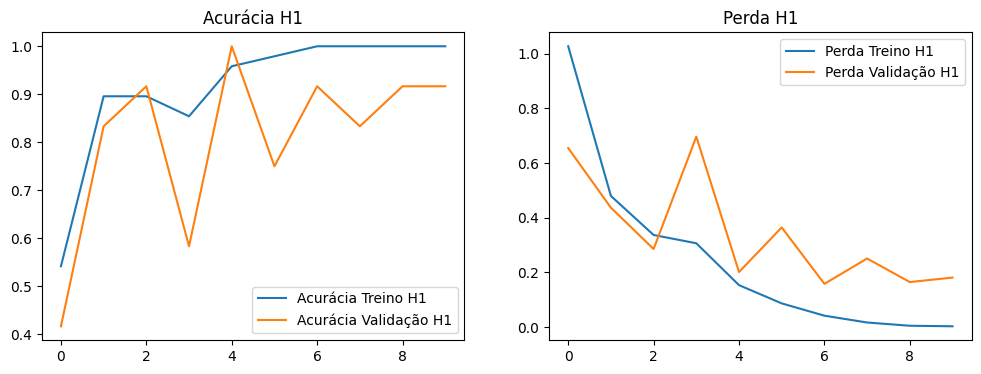

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


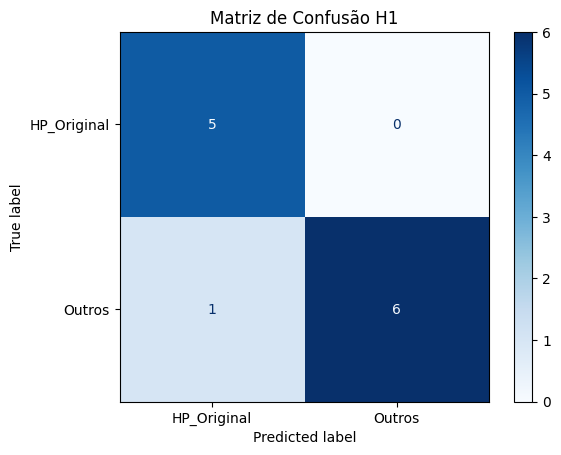

In [ ]:
# Carregar imagens de treino para H1
path_hp_original_h1 = base_dir_h1 / "HP_Original"
path_outros_h1 = base_dir_h1 / "Outros"

if not path_hp_original_h1.exists() or not path_outros_h1.exists() or \
   len(list(path_hp_original_h1.glob(f'*{TARGET_EXTENSION}'))) == 0 or \
   len(list(path_outros_h1.glob(f'*{TARGET_EXTENSION}'))) == 0:
    print(f"ERRO H1: Pastas 'HP_Original' ou 'Outros' não encontradas ou vazias em '{base_dir_h1}'.")
    print(f"         Certifique-se de que '{original_dataset_root_path_drive / 'HP_Original'}' e ")
    print(f"         '{original_dataset_root_path_drive / 'Outros'}' existem no seu Drive e contêm imagens .jpeg/.jpg.")
    train_ds_h1 = None
    val_ds_h1 = None
else:
    try:
        train_ds_h1 = tf.keras.utils.image_dataset_from_directory(
            base_dir_h1,
            validation_split=VALIDATION_SPLIT_H1,
            subset="training",
            seed=123,
            image_size=(IMG_HEIGHT_H1, IMG_WIDTH_H1),
            batch_size=BATCH_SIZE_H1,
            label_mode='binary', # Para duas classes (HP_Original vs Outros)
            class_names=['HP_Original', 'Outros'] # Garante a ordem das classes
        )

        val_ds_h1 = tf.keras.utils.image_dataset_from_directory(
            base_dir_h1,
            validation_split=VALIDATION_SPLIT_H1,
            subset="validation",
            seed=123,
            image_size=(IMG_HEIGHT_H1, IMG_WIDTH_H1),
            batch_size=BATCH_SIZE_H1,
            label_mode='binary',
            class_names=['HP_Original', 'Outros']
        )

        class_names_h1 = train_ds_h1.class_names
        print("Classes para H1:", class_names_h1)

        # Otimizar carregamento
        AUTOTUNE = tf.data.AUTOTUNE
        train_ds_h1 = train_ds_h1.cache().shuffle(100).prefetch(buffer_size=AUTOTUNE)
        val_ds_h1 = val_ds_h1.cache().prefetch(buffer_size=AUTOTUNE)

    except Exception as e:
        print(f"ERRO H1 ao carregar datasets: {e}")
        print("Verifique se as pastas 'HP_Original' e 'Outros' contêm APENAS as imagens para essas duas classes.")
        train_ds_h1 = None
        val_ds_h1 = None


if train_ds_h1 and val_ds_h1:
    # Modelo CNN (o mesmo que você tinha)
    model_h1 = keras.Sequential([
        layers.Rescaling(1./255, input_shape=(IMG_HEIGHT_H1, IMG_WIDTH_H1, 3)),
        layers.Conv2D(16, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # Saída binária
    ])

    model_h1.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    model_h1.summary()

    print(f"\nTreinando modelo H1 por {EPOCHS_H1} épocas...")
    history_h1 = model_h1.fit(
        train_ds_h1,
        validation_data=val_ds_h1,
        epochs=EPOCHS_H1
    )

    # Gráficos de Acurácia e Perda para H1
    if history_h1:
        acc = history_h1.history['accuracy']
        val_acc = history_h1.history['val_accuracy']
        loss = history_h1.history['loss']
        val_loss = history_h1.history['val_loss']
        epochs_range = range(EPOCHS_H1)

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, acc, label="Acurácia Treino H1")
        plt.plot(epochs_range, val_acc, label="Acurácia Validação H1")
        plt.legend()
        plt.title("Acurácia H1")

        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, loss, label="Perda Treino H1")
        plt.plot(epochs_range, val_loss, label="Perda Validação H1")
        plt.legend()
        plt.title("Perda H1")
        plt.show()

    # Matriz de Confusão para H1
    y_true_h1 = []
    y_pred_h1_probs = []
    for images, labels in val_ds_h1:
        preds = model_h1.predict(images)
        y_true_h1.extend(labels.numpy())
        y_pred_h1_probs.extend(preds.flatten())

    y_pred_h1 = (np.array(y_pred_h1_probs) > 0.5).astype(int)

    if y_true_h1 and class_names_h1:
        cm = confusion_matrix(y_true_h1, y_pred_h1)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_h1)
        disp.plot(cmap=plt.cm.Blues)
        plt.title("Matriz de Confusão H1")
        plt.show()
    else:
        print("AVISO H1: Dados para matriz de confusão incompletos.")
else:
    print("PULANDO TREINAMENTO DE H1 devido a erro no carregamento do dataset.")



```
3. HIPÓTESE H2: Similaridade Visual com Embeddings (ResNet50)
Objetivo: Encontrar anúncios visualmente similares ou distintos.
```



In [ ]:
print("\n\n--- Testando Hipótese H2: Similaridade com Embeddings ---")



--- Testando Hipótese H2: Similaridade com Embeddings ---


In [ ]:
# Parâmetros para H2
IMG_HEIGHT_EMB = 224 # ResNet50 usa tipicamente 224x224
IMG_WIDTH_EMB = 224

Encontradas 60 imagens em 'dataset_processed_local/general_ads_for_embeddings' para extração de embeddings H2.
Shape dos embeddings H2: (60, 2048)

Matriz de Similaridade de Cosseno (H2):
[[1.   0.66 0.64 ... 0.67 0.65 0.74]
 [0.66 1.   0.92 ... 0.77 0.92 0.69]
 [0.64 0.92 1.   ... 0.83 0.94 0.68]
 ...
 [0.67 0.77 0.83 ... 1.   0.8  0.62]
 [0.65 0.92 0.94 ... 0.8  1.   0.69]
 [0.74 0.69 0.68 ... 0.62 0.69 1.  ]]


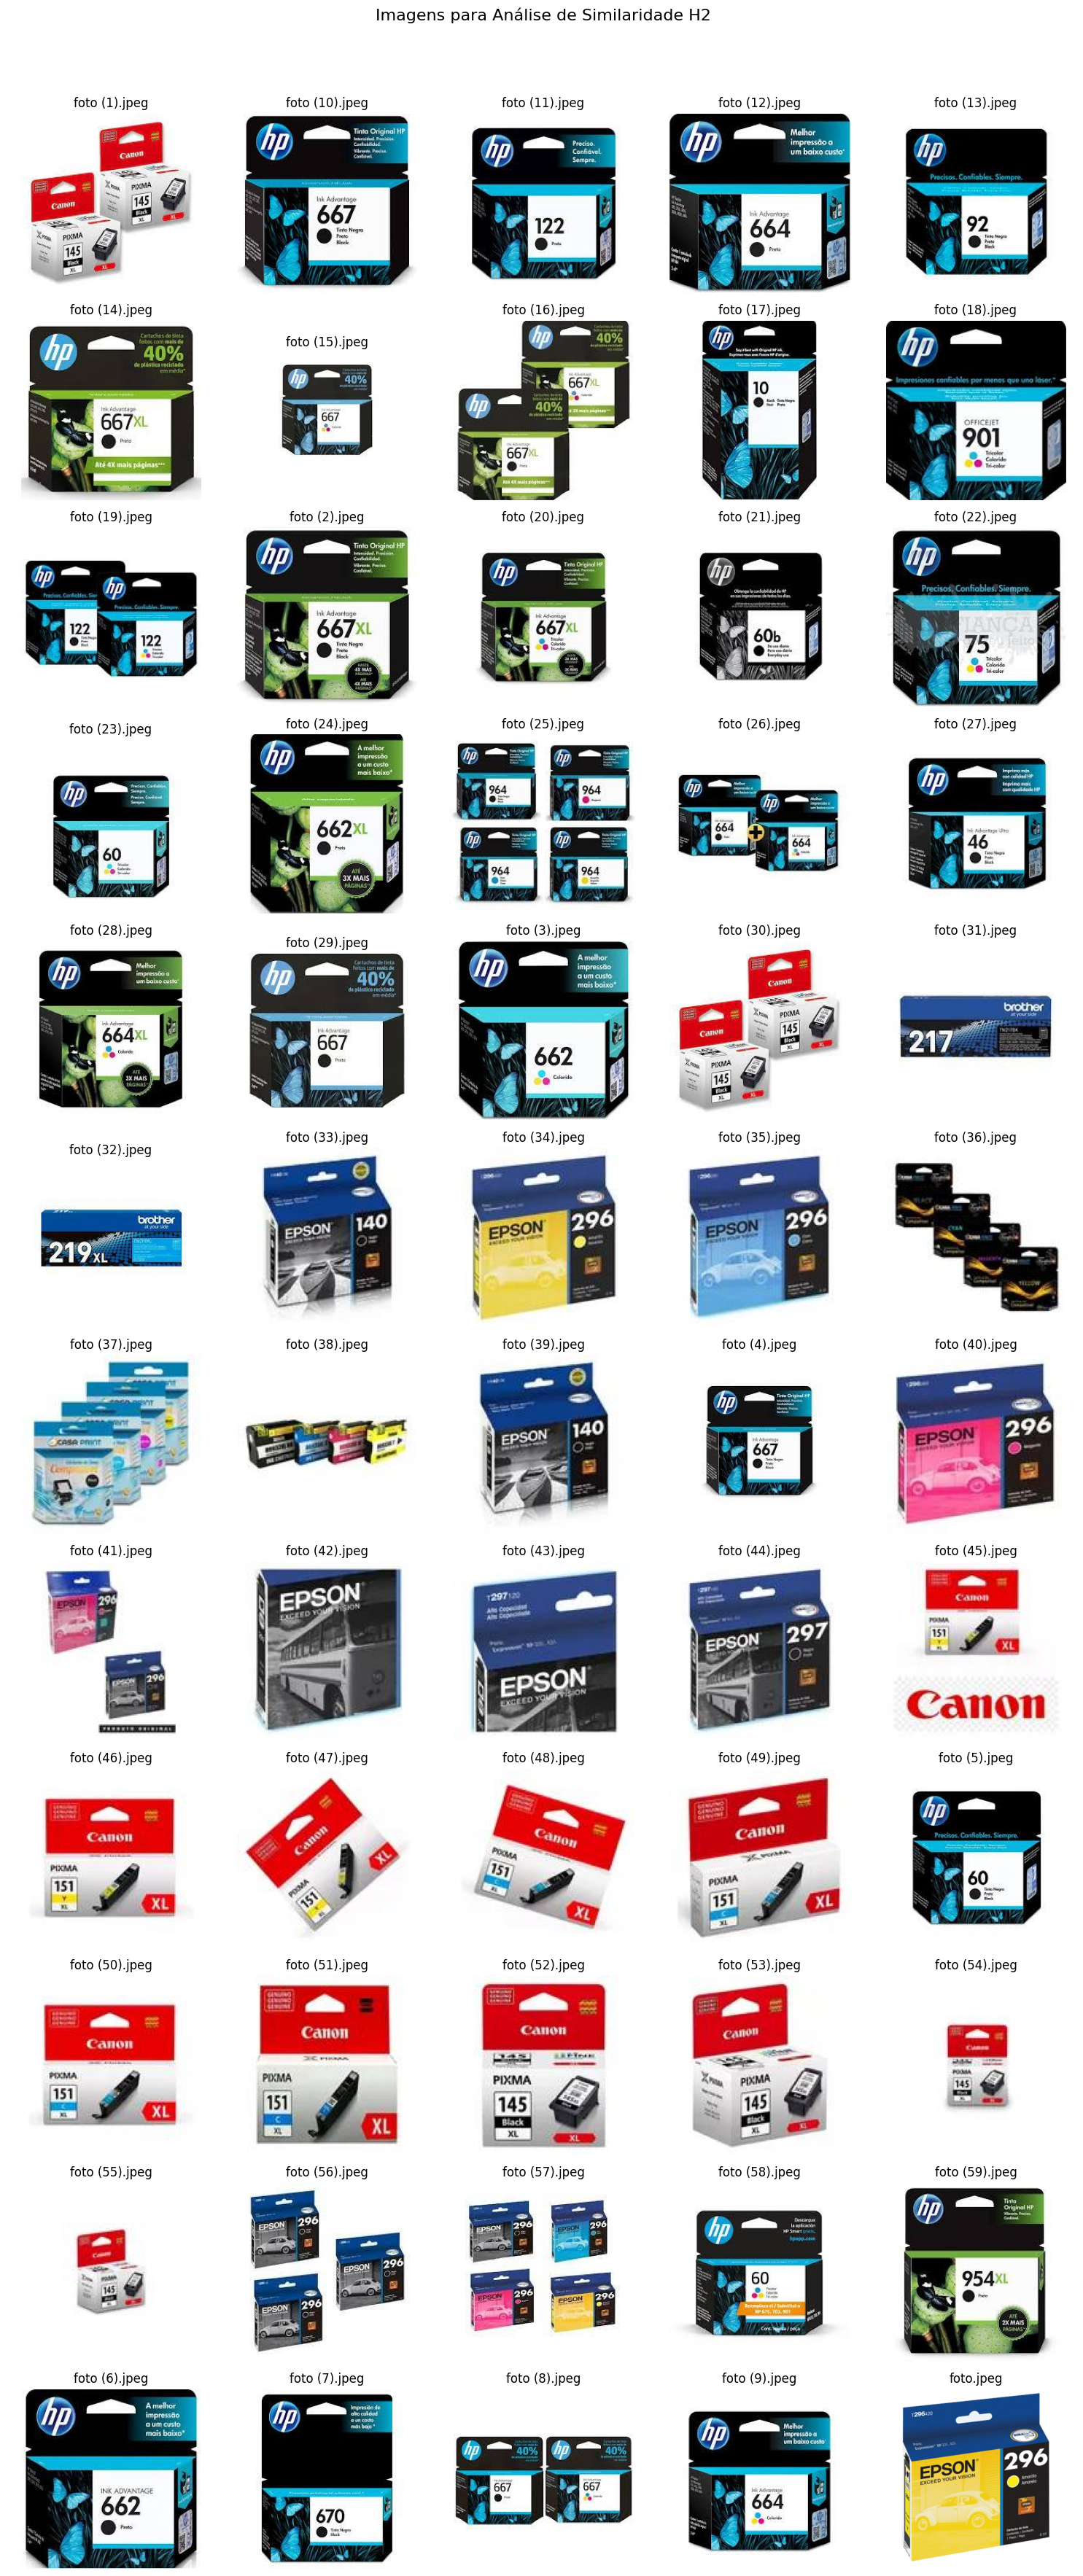

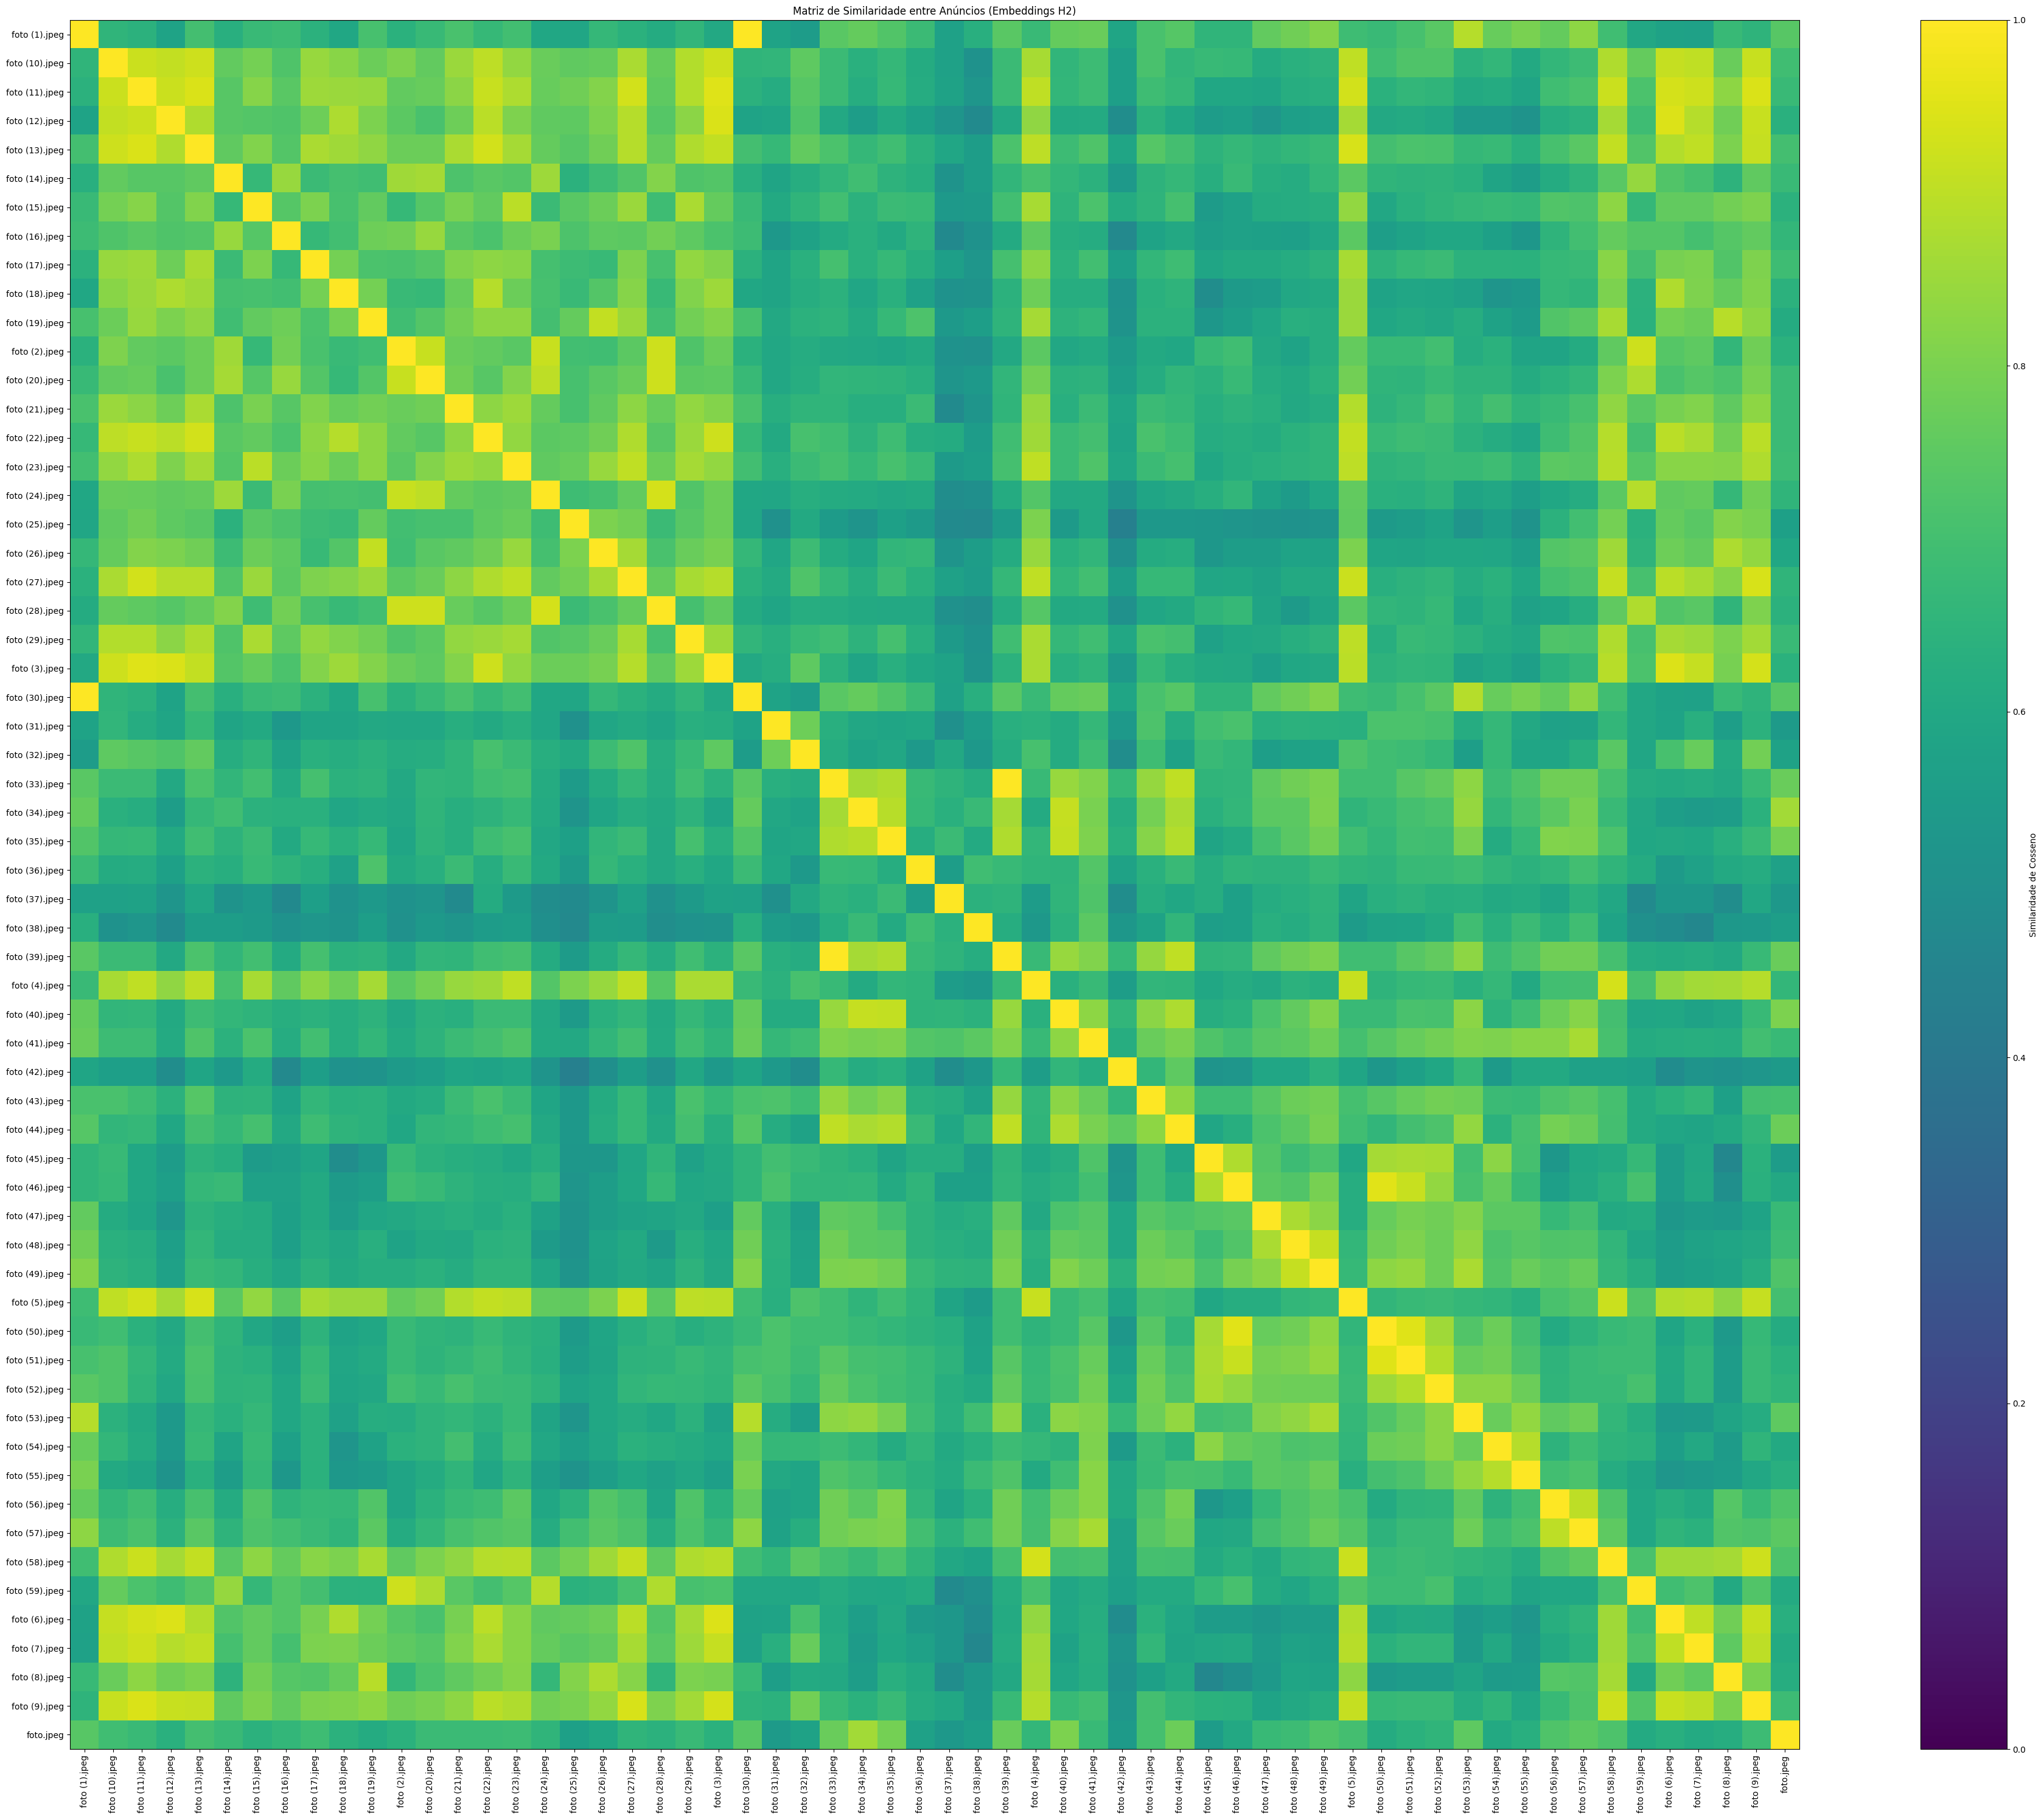


Pares com similaridade < 0.6 (potencialmente diferentes):
  - 'foto (1).jpeg' e 'foto (12).jpeg': 0.58
  - 'foto (1).jpeg' e 'foto (18).jpeg': 0.60
  - 'foto (1).jpeg' e 'foto (24).jpeg': 0.60
  - 'foto (1).jpeg' e 'foto (25).jpeg': 0.59
  - 'foto (1).jpeg' e 'foto (31).jpeg': 0.58
  - 'foto (1).jpeg' e 'foto (32).jpeg': 0.55
  - 'foto (1).jpeg' e 'foto (37).jpeg': 0.57
  - 'foto (1).jpeg' e 'foto (42).jpeg': 0.59
  - 'foto (1).jpeg' e 'foto (6).jpeg': 0.58
  - 'foto (1).jpeg' e 'foto (7).jpeg': 0.57
  - 'foto (10).jpeg' e 'foto (37).jpeg': 0.57
  - 'foto (10).jpeg' e 'foto (38).jpeg': 0.51
  - 'foto (10).jpeg' e 'foto (42).jpeg': 0.56
  - 'foto (11).jpeg' e 'foto (37).jpeg': 0.58
  - 'foto (11).jpeg' e 'foto (38).jpeg': 0.52
  - 'foto (11).jpeg' e 'foto (42).jpeg': 0.57
  - 'foto (11).jpeg' e 'foto (45).jpeg': 0.59
  - 'foto (11).jpeg' e 'foto (46).jpeg': 0.60
  - 'foto (11).jpeg' e 'foto (47).jpeg': 0.59
  - 'foto (11).jpeg' e 'foto (55).jpeg': 0.58
  - 'foto (12).jpeg' e 'foto (30)

In [ ]:
# Caminho para as imagens de anúncios gerais para embeddings
# Esta pasta deve ter sido criada e processada na Etapa 1
path_ads_for_embeddings = processed_dataset_local_path / folders_to_process_h2[0]

if not path_ads_for_embeddings.exists() or not any(path_ads_for_embeddings.glob(f'*{TARGET_EXTENSION}')):
    print(f"ERRO H2: Pasta '{path_ads_for_embeddings}' não encontrada ou vazia.")
    print(f"         Certifique-se de que '{original_dataset_root_path_drive / folders_to_process_h2[0]}' ")
    print(f"         existe no seu Drive e contém imagens .jpeg/.jpg de anúncios diversos.")
    all_features_h2 = None
else:
    # Carregar modelo ResNet50 pré-treinado
    base_model_h2 = ResNet50(weights='imagenet', include_top=False, pooling='avg',
                           input_shape=(IMG_HEIGHT_EMB, IMG_WIDTH_EMB, 3))
    model_h2_embeddings = Model(inputs=base_model_h2.input, outputs=base_model_h2.output)

    def extract_features_h2(img_path, model):
        img = load_img(img_path, target_size=(IMG_HEIGHT_EMB, IMG_WIDTH_EMB))
        img_array = img_to_array(img)
        expanded_img_array = np.expand_dims(img_array, axis=0)
        preprocessed_img = resnet_preprocess(expanded_img_array)
        features = model.predict(preprocessed_img, verbose=0)
        return features.flatten()

    ad_image_paths_h2 = [fp for fp in path_ads_for_embeddings.glob(f'*{TARGET_EXTENSION}')]
    ad_image_paths_h2.sort()

    if not ad_image_paths_h2:
        print(f"Nenhuma imagem {TARGET_EXTENSION} encontrada em '{path_ads_for_embeddings}' para H2.")
        all_features_h2 = None
    else:
        print(f"Encontradas {len(ad_image_paths_h2)} imagens em '{path_ads_for_embeddings}' para extração de embeddings H2.")
        all_features_h2 = []
        loaded_images_h2_pil = [] # Para plotagem
        image_labels_h2 = []

        for img_path in ad_image_paths_h2:
            try:
                features = extract_features_h2(img_path, model_h2_embeddings)
                all_features_h2.append(features)
                loaded_images_h2_pil.append(Image.open(img_path)) # Carrega com PIL para plot_images_h2
                image_labels_h2.append(img_path.name)
            except Exception as e:
                print(f"Erro ao processar {img_path.name} para H2: {e}")
                continue

        if not all_features_h2:
            print("Nenhum embedding foi extraído para H2.")
            all_features_h2 = None # Garante que é None se a lista estiver vazia
        else:
            all_features_h2 = np.array(all_features_h2)
            print(f"Shape dos embeddings H2: {all_features_h2.shape}")

            # Calcular similaridade de cosseno
            similarity_matrix_h2 = cosine_similarity(all_features_h2)
            print("\nMatriz de Similaridade de Cosseno (H2):")
            print(np.round(similarity_matrix_h2, 2))

            # Plotar as imagens e a matriz
            if loaded_images_h2_pil:
                plot_images_h2(loaded_images_h2_pil, labels=image_labels_h2, title="Imagens para Análise de Similaridade H2")

            plt.figure(figsize=(max(6, len(image_labels_h2) // 1.5), max(5, len(image_labels_h2) // 2))) # Ajusta tamanho
            plt.imshow(similarity_matrix_h2, cmap='viridis', vmin=0, vmax=1) # Limita escala de cor
            plt.colorbar(label='Similaridade de Cosseno')
            plt.title('Matriz de Similaridade entre Anúncios (Embeddings H2)')
            if image_labels_h2:
                plt.xticks(ticks=np.arange(len(image_labels_h2)), labels=image_labels_h2, rotation=90)
                plt.yticks(ticks=np.arange(len(image_labels_h2)), labels=image_labels_h2)
            plt.tight_layout()
            plt.show()

            # Exemplo de como identificar pares "diferentes" e "similares"
            similarity_threshold_different = 0.6 # Ajustar conforme necessário
            similarity_threshold_similar = 0.9   # Ajustar conforme necessário
            print(f"\nPares com similaridade < {similarity_threshold_different} (potencialmente diferentes):")
            for i in range(len(all_features_h2)):
                for j in range(i + 1, len(all_features_h2)):
                    if similarity_matrix_h2[i, j] < similarity_threshold_different:
                        print(f"  - '{image_labels_h2[i]}' e '{image_labels_h2[j]}': {similarity_matrix_h2[i,j]:.2f}")

            print(f"\nPares com similaridade > {similarity_threshold_similar} (potencialmente muito similares):")
            for i in range(len(all_features_h2)):
                for j in range(i + 1, len(all_features_h2)):
                    if similarity_matrix_h2[i, j] > similarity_threshold_similar:
                        print(f"  - '{image_labels_h2[i]}' e '{image_labels_h2[j]}': {similarity_matrix_h2[i,j]:.2f}")

            # Opcional: Clustering (KMeans)
            if len(all_features_h2) >= 2:
                num_clusters = min(3, len(all_features_h2)) # Exemplo: 3 clusters, ou menos
                if num_clusters > 0:
                    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
                    cluster_labels = kmeans.fit_predict(all_features_h2)
                    print("\nLabels dos Clusters (H2 - KMeans):")
                    for img_label, label in zip(image_labels_h2, cluster_labels):
                        print(f"  - '{img_label}': Cluster {label}")
if all_features_h2 is None:
     print("PULANDO ANÁLISE DE EMBEDDINGS H2 devido a erro no carregamento ou processamento das imagens.")



```
4. Hipóteses H3 (Estilo - Conceitual) e H4 (Autoencoder - Conceitual)
```



In [ ]:
print("\n\n--- Hipóteses Conceituais para Sprint 1 (requerem mais dados/rotulagem) ---")
print("H3: Classificação de Estilo/Atributo de Anúncio (CNN)")
print("   - Descrição: Treinar uma CNN para classificar anúncios por atributos estilísticos (e.g., 'minimalista', 'colorido', 'foco no produto', 'foco no lifestyle').")
print("   - Como indica diferença: Anúncios classificados em estilos diferentes são, por definição, distintos nesse aspecto.")
print("   - Teste: Similar à H1, mas com labels de estilo. Requereria um dataset mais substancial e bem rotulado.")
print("   - Poderia usar transfer learning e adicionar camadas de classificação.")

print("\nH4: Detecção de Anomalias em Anúncios (Autoencoders)")
print("   - Descrição: Treinar um autoencoder em um conjunto de anúncios 'padrão' ou 'baseline' (e.g., anúncios típicos da HP).")
print("   - Como indica diferença: Anúncios com alta taxa de erro de reconstrução ao passar pelo autoencoder seriam considerados 'diferentes' ou 'anômalos' em relação ao padrão aprendido.")
print("   - Teste: Treinar um autoencoder simples. Testar em imagens 'anormais' e comparar o MSE.")



--- Hipóteses Conceituais para Sprint 1 (requerem mais dados/rotulagem) ---
H3: Classificação de Estilo/Atributo de Anúncio (CNN)
   - Descrição: Treinar uma CNN para classificar anúncios por atributos estilísticos (e.g., 'minimalista', 'colorido', 'foco no produto', 'foco no lifestyle').
   - Como indica diferença: Anúncios classificados em estilos diferentes são, por definição, distintos nesse aspecto.
   - Teste: Similar à H1, mas com labels de estilo. Requereria um dataset mais substancial e bem rotulado.
   - Poderia usar transfer learning e adicionar camadas de classificação.

H4: Detecção de Anomalias em Anúncios (Autoencoders)
   - Descrição: Treinar um autoencoder em um conjunto de anúncios 'padrão' ou 'baseline' (e.g., anúncios típicos da HP).
   - Como indica diferença: Anúncios com alta taxa de erro de reconstrução ao passar pelo autoencoder seriam considerados 'diferentes' ou 'anômalos' em relação ao padrão aprendido.
   - Teste: Treinar um autoencoder simples. Testar em

In [ ]:
# Exemplo conceitual de arquitetura de Autoencoder
# input_img_ae = Input(shape=(IMG_HEIGHT_H1, IMG_WIDTH_H1, 3)) # Usando dimensões de H1 como exemplo
# # Encoder
# x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img_ae)
# x = MaxPooling2D((2,2), padding='same')(x)
# x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
# encoded = MaxPooling2D((2,2), padding='same')(x)
# # Decoder
# x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
# x = layers.UpSampling2D((2,2))(x)
# x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
# x = layers.UpSampling2D((2,2))(x)
# decoded_ae = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x) # Reconstrução para 3 canais
# autoencoder_h4 = Model(input_img_ae, decoded_ae)
# autoencoder_h4.compile(optimizer='adam', loss='mse')
# print("   (Exemplo de sumário de Autoencoder H4 abaixo se a célula fosse executada)")
# # autoencoder_h4.summary()



```
5. Conclusões Preliminares e Próximos Passos (do Sprint)
```



In [ ]:
print("\n\n--- Conclusões Preliminares (Sprint 1) ---")
print("1. H1 (Classificação CNN de Conteúdo/Tipo):")
print("   - Viabilidade: Demonstrou ser viável classificar anúncios com base em seu conteúdo (e.g., 'HP_Original' vs 'Outros').")
print("   - Diferenças: Anúncios são considerados diferentes se o modelo os atribui a classes distintas.")
print("   - Limitações: Performance depende da qualidade/quantidade dos dados e da clareza das classes.")
print("2. H2 (Embeddings e Similaridade Visual):")
print("   - Viabilidade: Eficaz para quantificar similaridade/diferença visual geral entre anúncios usando embeddings de modelos pré-treinados.")
print("   - Diferenças: Anúncios com baixa similaridade de cosseno ou pertencentes a clusters diferentes são visualmente distintos.")
print("   - Vantagens: Não requer treinamento de um modelo do zero para extração de features se usarmos modelos como ResNet50.")
print("3. H3 e H4 (Conceituais):")
print("   - Potencial: São hipóteses promissoras para análises mais profundas (estilo, anomalia).")
print("   - Requisitos: Requerem datasets maiores, possivelmente rotulados especificamente para essas tarefas.")

print("\n--- Como essas estratégias podem ser usadas nas próximas etapas do Challenge da HP (Análise de Anúncios) ---")
print("- Base para Análise Comparativa:")
print("  - H1: Expandir para classificar tipos de anúncios da HP vs. concorrentes (e.g., por produto anunciado, por campanha, por presença de logo).")
print("  - H2: Mapear o 'espaço visual' dos anúncios da HP em relação aos concorrentes. Identificar se os anúncios da HP são visualmente distintos ou se agrupam com os de certos concorrentes. Rastrear a evolução visual de campanhas.")
print("- Identificação de Estilos e Tendências:")
print("  - H3 (desenvolvimento futuro): Classificar anúncios por estilo (moderno, tradicional, focado em tecnologia, focado em pessoas) para entender o posicionamento visual da HP e dos concorrentes.")
print("- Garantia de Consistência de Marca e Detecção de Outliers:")
print("  - H4 (desenvolvimento futuro): Treinar um autoencoder com anúncios 'padrão' da HP para identificar anúncios (internos ou de terceiros) que fogem da identidade visual esperada, ou para detectar campanhas de concorrentes que são radicalmente diferentes.")
print("- Benchmarking e Monitoramento:")
print("  - H2: Encontrar os anúncios de concorrentes mais similares (ou mais diferentes) a uma campanha específica da HP.")
print("- Alimentar Estratégias Criativas:")
print("  - Identificar 'espaços visuais' menos explorados no mercado de anúncios que a HP poderia ocupar.")
print("- Automação:")
print("  - Desenvolver pipelines para processar e analisar grandes volumes de novos anúncios automaticamente.")
print("- Definição de Métricas de 'Diferença':")
print("  - É crucial definir com a HP o que constitui uma 'diferença significativa' para os objetivos de negócio (e.g., diferença na cor predominante, nos objetos presentes, no estilo geral).")



--- Conclusões Preliminares (Sprint 1) ---
1. H1 (Classificação CNN de Conteúdo/Tipo):
   - Viabilidade: Demonstrou ser viável classificar anúncios com base em seu conteúdo (e.g., 'HP_Original' vs 'Outros').
   - Diferenças: Anúncios são considerados diferentes se o modelo os atribui a classes distintas.
   - Limitações: Performance depende da qualidade/quantidade dos dados e da clareza das classes.
2. H2 (Embeddings e Similaridade Visual):
   - Viabilidade: Eficaz para quantificar similaridade/diferença visual geral entre anúncios usando embeddings de modelos pré-treinados.
   - Diferenças: Anúncios com baixa similaridade de cosseno ou pertencentes a clusters diferentes são visualmente distintos.
   - Vantagens: Não requer treinamento de um modelo do zero para extração de features se usarmos modelos como ResNet50.
3. H3 e H4 (Conceituais):
   - Potencial: São hipóteses promissoras para análises mais profundas (estilo, anomalia).
   - Requisitos: Requerem datasets maiores, possivelme



```
6. EXPORTAÇÃO PARA TFLITE (OPCIONAL - do modelo H1)
```



In [ ]:
if train_ds_h1 and val_ds_h1: # Somente se o modelo H1 foi treinado
    print("\n\n--- Exportação do Modelo H1 para TFLite (Opcional) ---")
    try:
        converter = tf.lite.TFLiteConverter.from_keras_model(model_h1)
        tflite_model = converter.convert()
        with open("modelo_classificador_anuncios_h1.tflite", "wb") as f:
            f.write(tflite_model)
        print("Modelo H1 exportado como modelo_classificador_anuncios_h1.tflite")
    except Exception as e:
        print(f"Erro ao exportar modelo H1 para TFLite: {e}")
else:
    print("\n\nModelo H1 não treinado, pulando exportação para TFLite.")

print("\n\n--- Script Concluído ---")



--- Exportação do Modelo H1 para TFLite (Opcional) ---
Saved artifact at '/tmp/tmpuryus6cz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_188')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133678075850640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133678075852176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133678075851600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133678075852944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133678075852368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133678075853712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133678451816208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133678451814672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133678450295248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133678450295056: Tensor